# Feature Engineering
Build the feature matrix, check distributions, label balance, and run a naive first model.

In [9]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add infrastructure/ml to path
REPO = Path('../../..').resolve()
sys.path.insert(0, str(REPO / 'infrastructure' / 'ml' / 'features'))

from build_dataset import build_features, build_all, save_all, UNIVERSE, DEADBAND

FEATURES_DIR = REPO / 'topics' / 'ml-prediction' / 'data' / 'features'
print('Repo root:', REPO)

Repo root: C:\Users\user\Documents\Epsilon Fund\Epsilon-Quant-Research


## Build feature matrix
Runs for all 8 symbols and saves parquets to `data/features/`.

In [10]:
print('Building features...')
save_all()

Building features...
  BTCUSDT... 

2155 rows, 1856 labelled (86% survive deadband)
  ETHUSDT... 2155 rows, 1949 labelled (90% survive deadband)
  SOLUSDT... 2088 rows, 1966 labelled (94% survive deadband)
  BNBUSDT... 2500 rows, 2234 labelled (89% survive deadband)
  XRPUSDT... 2155 rows, 1953 labelled (91% survive deadband)
  DOGEUSDT... 2489 rows, 2273 labelled (91% survive deadband)
  LINKUSDT... 2155 rows, 2041 labelled (95% survive deadband)
  AVAXUSDT... 2046 rows, 1950 labelled (95% survive deadband)


## Load and inspect

In [11]:
# Load all into one DataFrame
dfs = {}
for sym in UNIVERSE:
    p = FEATURES_DIR / f'{sym}_features.parquet'
    if p.exists():
        dfs[sym] = pd.read_parquet(p)

all_df = pd.concat(dfs.values())
feature_cols = [c for c in all_df.columns if c not in ('label', 'next_ret', 'symbol')]

print(f'Total rows:     {len(all_df):,}')
print(f'Labelled rows:  {all_df["label"].notna().sum():,}')
print(f'Deadband drop:  {all_df["label"].isna().sum():,} rows ({100*all_df["label"].isna().mean():.1f}%)')
print(f'Feature count:  {len(feature_cols)}')
print(f'\nLabel balance (labelled rows only):')
labelled = all_df[all_df['label'].notna()]
print(labelled['label'].value_counts(normalize=True).round(3))

Total rows:     17,743
Labelled rows:  16,222
Deadband drop:  1,521 rows (8.6%)
Feature count:  35

Label balance (labelled rows only):
label
1.0    0.505
0.0    0.495
Name: proportion, dtype: float64


## Label balance per symbol

In [12]:
print(f'  {"SYMBOL":<12} {"TOTAL":>6} {"LABELLED":>9} {"SURVIVE%":>9} {"LONG%":>7} {"SHORT%":>7}')
print('-' * 60)
for sym, df in dfs.items():
    lab = df[df['label'].notna()]
    pct_survive = 100 * len(lab) / len(df)
    pct_long    = 100 * (lab['label'] == 1).mean()
    pct_short   = 100 * (lab['label'] == 0).mean()
    print(f'  {sym:<12} {len(df):>6} {len(lab):>9} {pct_survive:>8.1f}% {pct_long:>6.1f}% {pct_short:>6.1f}%')

  SYMBOL        TOTAL  LABELLED  SURVIVE%   LONG%  SHORT%
------------------------------------------------------------
  BTCUSDT        2155      1856     86.1%   51.3%   48.7%
  ETHUSDT        2155      1949     90.4%   51.8%   48.2%
  SOLUSDT        2088      1966     94.2%   49.3%   50.7%
  BNBUSDT        2500      2234     89.4%   52.5%   47.5%
  XRPUSDT        2155      1953     90.6%   49.9%   50.1%
  DOGEUSDT       2489      2273     91.3%   48.6%   51.4%
  LINKUSDT       2155      2041     94.7%   51.0%   49.0%
  AVAXUSDT       2046      1950     95.3%   49.3%   50.7%


## Null coverage per feature
Features with high null % need special handling at training time.

In [13]:
null_pct = all_df[feature_cols].isna().mean().sort_values(ascending=False) * 100
print('Features with >10% nulls:')
print(null_pct[null_pct > 10].round(1).to_string())
print(f'\nFeatures with 0% nulls: {(null_pct == 0).sum()}')

Features with >10% nulls:
dvol_chg_7d     88.8
dvol            88.7
spx_ret_7d      31.4
spx_ret_1d      31.4
gold_ret_1d     31.2
gold_ret_7d     31.2
dxy_ret_7d      31.2
dxy_ret_1d      31.2
ls_chg_7d       26.3
ls_ratio        25.7
oi_chg_7d       25.2
oi_chg_1d       24.9
btc_beta_30d    17.2
btc_corr_30d    17.2

Features with 0% nulls: 4


## Feature distributions (BTC)

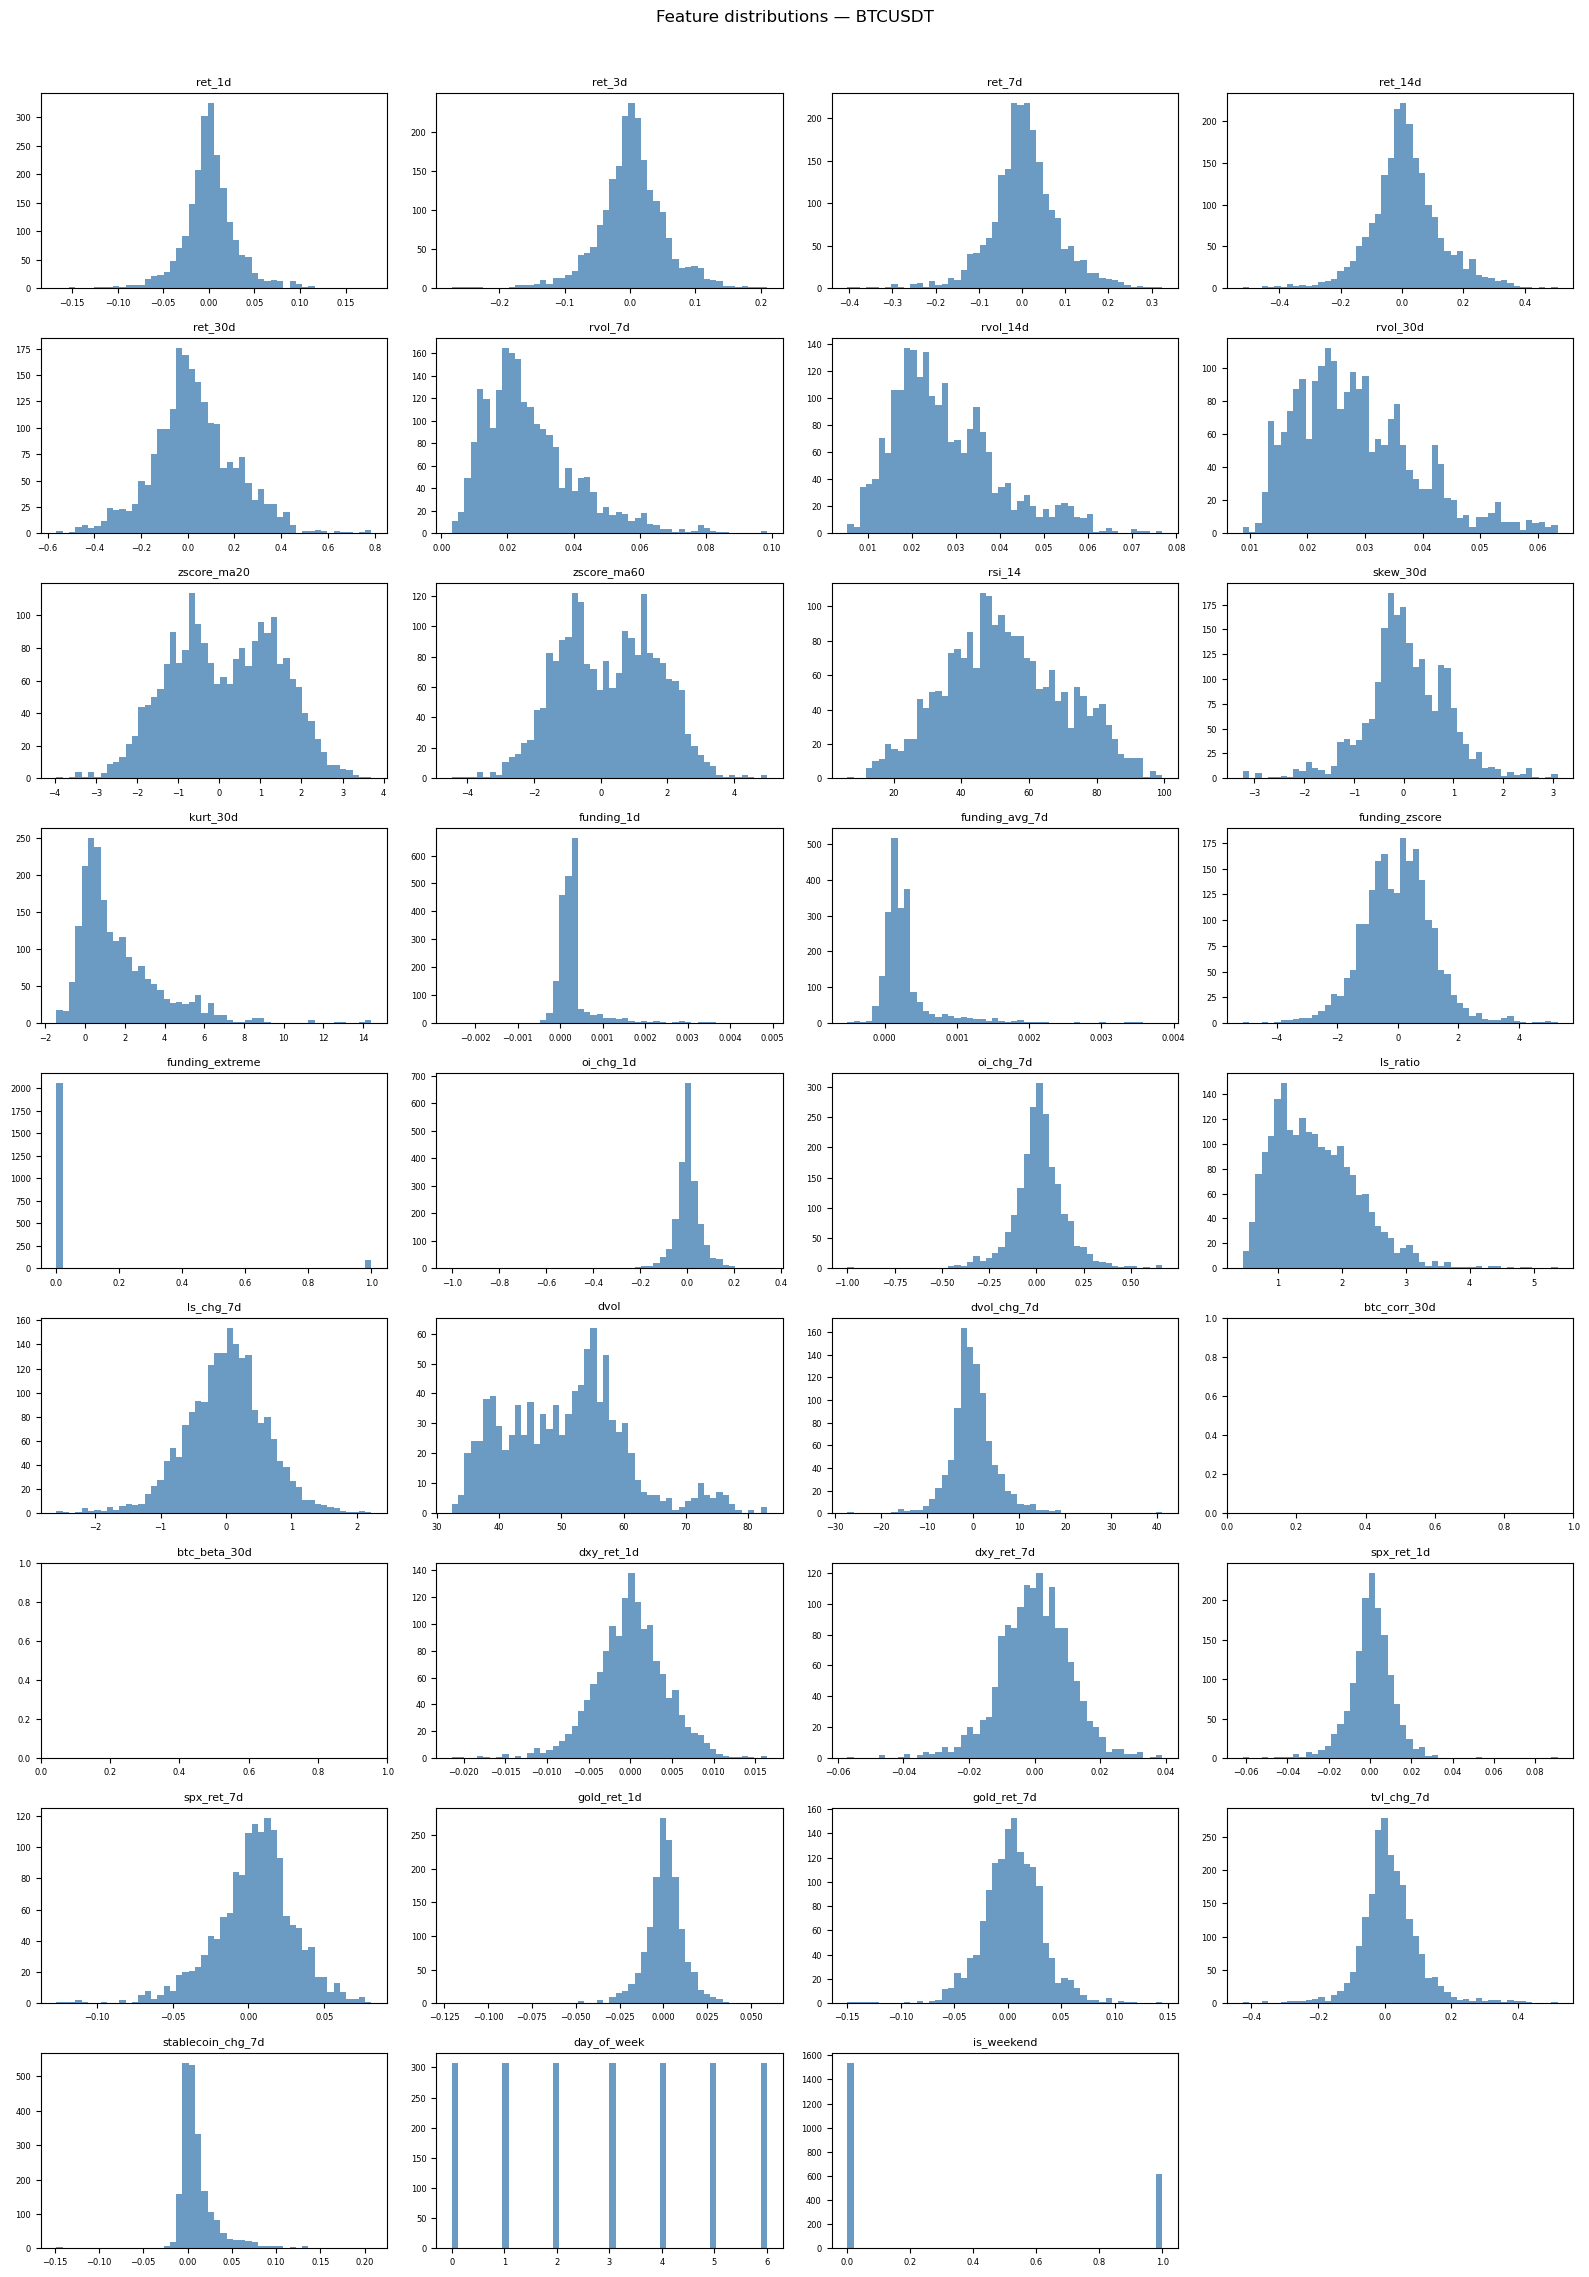

In [14]:
btc = dfs['BTCUSDT'][feature_cols].dropna(how='all')
n_cols = len(feature_cols)
n_rows = (n_cols + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    s = btc[col].dropna()
    if len(s) > 0:
        axes[i].hist(s, bins=50, edgecolor='none', color='steelblue', alpha=0.8)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature distributions — BTCUSDT', y=1.01)
plt.tight_layout()
plt.show()

## Correlation with label (BTC)

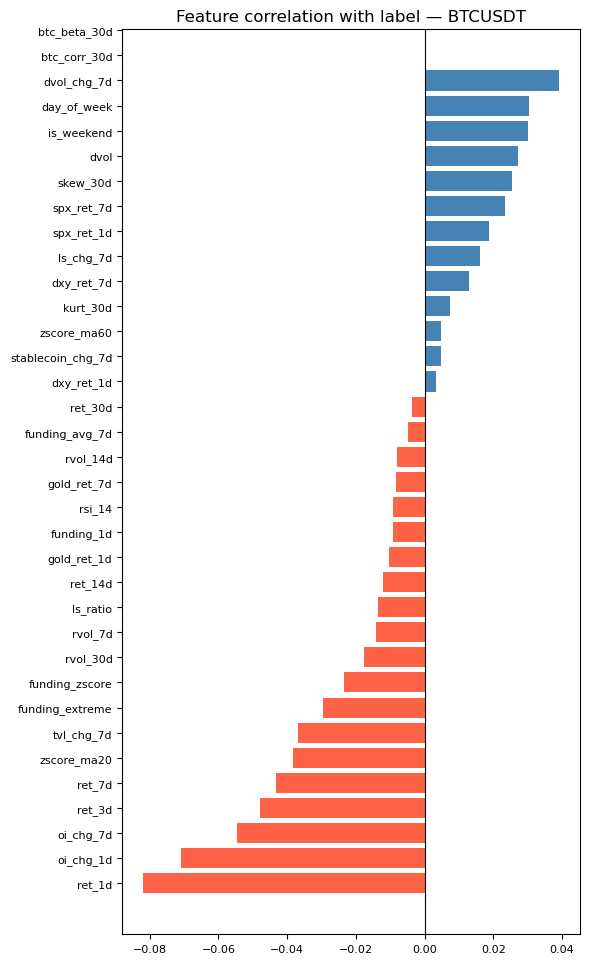

In [15]:
btc_lab = dfs['BTCUSDT'][dfs['BTCUSDT']['label'].notna()]
corr = btc_lab[feature_cols].corrwith(btc_lab['label']).sort_values()

fig, ax = plt.subplots(figsize=(6, len(corr) * 0.25 + 1))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature correlation with label — BTCUSDT')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

## Naive first model
XGBoost on price features only, single train/test split (no walk-forward yet).
Target: hit rate > 52% on holdout. If not, there's a data join bug.

In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

price_feat = [c for c in feature_cols if any(c.startswith(p) for p in
              ('ret_', 'rvol_', 'zscore_', 'rsi_', 'skew_', 'kurt_'))]

# Pool all symbols
pooled = all_df[all_df['label'].notna()][price_feat + ['label']].dropna()

# Chronological split — 80% train, 20% test
split_idx = int(len(pooled) * 0.8)
train = pooled.iloc[:split_idx]
test  = pooled.iloc[split_idx:]

X_train, y_train = train[price_feat], train['label']
X_test,  y_test  = test[price_feat],  test['label']

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0,
)
model.fit(X_train, y_train)

preds     = model.predict(X_test)
hit_rate  = accuracy_score(y_test, preds)
baseline  = max(y_test.mean(), 1 - y_test.mean())

print(f'Hit rate:  {hit_rate:.3f}')
print(f'Baseline:  {baseline:.3f}  (majority class)')
print(f'Edge:      {hit_rate - baseline:+.3f}')
print()
if hit_rate > 0.52:
    print('> 52% — signal exists. Proceed to walk-forward.')
else:
    print('< 52% — check data join and label construction before proceeding.')

Hit rate:  0.527
Baseline:  0.503  (majority class)
Edge:      +0.024

> 52% — signal exists. Proceed to walk-forward.
